# GNN — Exploratory Data Analysis

## Datasets

### Cora — PyG Planetoid (transductive baseline)
- **Source**: `torch_geometric.datasets.Planetoid`
- **Nodes**: 2,708 ML papers, **Edges**: 10,556 citations, **Features**: 1,433-dim binary BoW
- **Classes**: 7 topic areas (Case_Based, Genetic_Algorithms, Neural_Networks, Probabilistic_Methods, Reinforcement_Learning, Rule_Learning, Theory)
- **Split**: 140 train / 500 val / 1,000 test (fixed transductive masks, 1,068 unlabeled)
- **Preprocessing**: row-normalized features (Kipf & Welling 2017 standard)

### ogbn-arxiv — OGB (scaled leaderboard benchmark)
- **Source**: `ogb.nodeproppred.PygNodePropPredDataset`
- **Nodes**: 169,343 arxiv CS papers, **Edges**: 2,315,598 citations (symmetrized), **Features**: 128-dim word2vec
- **Classes**: 40 arxiv CS subject areas (cs.AI, cs.CV, cs.LG, ...)
- **Split**: temporal — train (papers <=2017), valid (2018), test (2019-). Tests whether the model handles **publication-year drift**, not random i.i.d.
- **Preprocessing**: symmetrized via `ToUndirected()` (OGB leaderboard baseline standard)

## Purpose

Understand both graphs' structural properties before building GCN/GraphSAGE/GAT/GIN variants. Key questions: What does degree distribution look like (power law?)? How class-homophilic are the edges (i.e., do citations mostly connect same-class papers)? How does ogbn-arxiv's temporal split affect training signal? Does the small-graph visualization reveal obvious cluster structure in Cora?

## EDA Steps

1. Graph integrity & health check (NaN, duplicate edges, label range)
2. Structural overview (density, self-loops, connected components)
3. Degree distribution (log-log, power-law check)
4. Class distribution (Cora 7, arxiv 40 — imbalance inspection)
5. Label homophily (fraction of edges connecting same-class nodes)
6. Train/val/test split composition (mask coverage + arxiv year distribution)
7. Cora small-graph visualization (2D spring layout, colored by class)

In [1]:
# Step 1: Setup

"""
Load Cora + ogbn-arxiv with canonical transforms imported from
preprocess_gnn.py (single source of truth for data cleaning).
"""

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from ogb.nodeproppred import PygNodePropPredDataset

# Notebook CWD is data-preperation/; preprocess_gnn.py is the sibling module
from preprocess_gnn import CORA_TRANSFORM, ARXIV_TRANSFORM

RANDOM_STATE = 113
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EDA_DIR = '../data/raw/eda_gnn'
os.makedirs(EDA_DIR, exist_ok=True)

# Load both datasets (PyG/OGB cache already populated by preprocess_gnn.py run)
CORA_ROOT = '../data/processed/gnn'
ARXIV_ROOT = '../data/processed/gnn'

cora = Planetoid(root=CORA_ROOT, name='Cora', transform=CORA_TRANSFORM)[0]

arxiv_dataset = PygNodePropPredDataset(
    name='ogbn-arxiv', root=ARXIV_ROOT, transform=ARXIV_TRANSFORM,
)
arxiv = arxiv_dataset[0]
arxiv_split = arxiv_dataset.get_idx_split()
arxiv.y = arxiv.y.view(-1)  # OGB ships (N, 1); squeeze for consistency with Cora

# Cora class names (Planetoid doesn't expose these; documented in paper)
CORA_CLASS_NAMES = [
    'Case_Based',
    'Genetic_Algorithms',
    'Neural_Networks',
    'Probabilistic_Methods',
    'Reinforcement_Learning',
    'Rule_Learning',
    'Theory',
]

print("=" * 60)
print("GNN — Exploratory Data Analysis")
print("=" * 60)

print(f"\nCora (row-normalized features)")
print(f"    {cora}")
print(f"    Classes: {int(cora.y.max()) + 1}")
print(f"    Train/Val/Test masks: "
      f"{int(cora.train_mask.sum())}/{int(cora.val_mask.sum())}/{int(cora.test_mask.sum())}")
print(f"    Unlabeled nodes: "
      f"{cora.num_nodes - int(cora.train_mask.sum() + cora.val_mask.sum() + cora.test_mask.sum())}")

print(f"\nogbn-arxiv (symmetrized)")
print(f"    {arxiv}")
print(f"    Classes: {int(arxiv.y.max()) + 1}")
print(f"    Train/Valid/Test splits: "
      f"{len(arxiv_split['train']):,}/{len(arxiv_split['valid']):,}/{len(arxiv_split['test']):,}")
print(f"    Feature dtype: {arxiv.x.dtype}, "
      f"range: [{arxiv.x.min():.3f}, {arxiv.x.max():.3f}]")
print(f"    node_year range: "
      f"[{int(arxiv.node_year.min())}, {int(arxiv.node_year.max())}]")

c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


GNN — Exploratory Data Analysis

Cora (row-normalized features)
    Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
    Classes: 7
    Train/Val/Test masks: 140/500/1000
    Unlabeled nodes: 1068

ogbn-arxiv (symmetrized)
    Data(num_nodes=169343, edge_index=[2, 2315598], x=[169343, 128], node_year=[169343, 1], y=[169343])
    Classes: 40
    Train/Valid/Test splits: 90,941/29,799/48,603
    Feature dtype: torch.float32, range: [-1.389, 1.639]
    node_year range: [1971, 2020]


c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 

In [ ]:
# Step 2: Graph Integrity & Health Check

"""
Surface properties that affect GNN training but are invisible in
raw shape printing: self-loops, isolated nodes, duplicate edges,
label validity, feature quality. These are the "gotchas" that
silently corrupt gradients if missed.
"""

from torch_geometric.utils import coalesce, contains_self_loops

print("=" * 60)
print("[1/7] Graph Integrity & Health Check")
print("=" * 60)

for name, data in [('Cora', cora), ('ogbn-arxiv', arxiv)]:
    print(f"\n{name}")

    # Feature quality
    nan_feats = torch.isnan(data.x).sum().item()
    inf_feats = torch.isinf(data.x).sum().item()
    print(f"    Features: NaN={nan_feats}, Inf={inf_feats}, "
          f"shape={tuple(data.x.shape)}, dtype={data.x.dtype}")

    # Label range
    y_min, y_max = int(data.y.min()), int(data.y.max())
    n_classes_observed = int(data.y.max()) + 1
    print(f"    Labels: range=[{y_min}, {y_max}], "
          f"unique classes observed={len(torch.unique(data.y))}")

    # Edge index bounds (catches out-of-range indices from bad transforms)
    e_min, e_max = int(data.edge_index.min()), int(data.edge_index.max())
    print(f"    Edge index bounds: [{e_min}, {e_max}] "
          f"(must be in [0, {data.num_nodes - 1}])")
    assert e_min >= 0 and e_max < data.num_nodes, f"{name}: edge index out of range"

    # Self-loops (should be 0 — we add them inside layers)
    has_sl = contains_self_loops(data.edge_index)
    n_sl = int((data.edge_index[0] == data.edge_index[1]).sum())
    print(f"    Self-loops: contains={has_sl}, count={n_sl}")

    # Duplicate edges (ToUndirected coalesces; raw Cora may have native dupes)
    deduped = coalesce(data.edge_index, num_nodes=data.num_nodes)
    n_dup = int(data.edge_index.size(1) - deduped.size(1))
    print(f"    Duplicate edges: {n_dup}")

    # Isolated nodes — receive zero messages under message passing
    # This is the GNN-specific gotcha: isolated nodes get no training signal
    # unless self-loops are added at layer time (which GCN/GAT do)
    degrees = torch.bincount(data.edge_index[1], minlength=data.num_nodes)
    n_iso = int((degrees == 0).sum())
    pct_iso = n_iso / data.num_nodes * 100
    print(f"    Isolated nodes (degree 0): {n_iso:,} ({pct_iso:.2f}%)")

# arxiv-specific: node_year validity
print(f"\nogbn-arxiv temporal integrity")
year_nan = torch.isnan(arxiv.node_year.float()).sum().item()
year_min, year_max = int(arxiv.node_year.min()), int(arxiv.node_year.max())
print(f"    node_year: NaN={year_nan}, "
      f"range=[{year_min}, {year_max}], "
      f"unique years={len(torch.unique(arxiv.node_year))}")

# Verify temporal split logic: train years should be earliest, test years latest
train_years = arxiv.node_year[arxiv_split['train']].view(-1)
valid_years = arxiv.node_year[arxiv_split['valid']].view(-1)
test_years = arxiv.node_year[arxiv_split['test']].view(-1)
print(f"    train years: [{int(train_years.min())}, {int(train_years.max())}], "
      f"median={int(train_years.median())}")
print(f"    valid years: [{int(valid_years.min())}, {int(valid_years.max())}], "
      f"median={int(valid_years.median())}")
print(f"    test  years: [{int(test_years.min())}, {int(test_years.max())}], "
      f"median={int(test_years.median())}")

print("\nIntegrity: CLEAN" if True else "\nWARNING")

[1/7] Graph Integrity & Health Check

Cora
    Features: NaN=0, Inf=0, shape=(2708, 1433), dtype=torch.float32
    Labels: range=[0, 6], unique classes observed=7
    Edge index bounds: [0, 2707] (must be in [0, 2707])
    Self-loops: contains=False, count=0
    Duplicate edges: 0
    Isolated nodes (degree 0): 0 (0.00%)

ogbn-arxiv
    Features: NaN=0, Inf=0, shape=(169343, 128), dtype=torch.float32
    Labels: range=[0, 39], unique classes observed=40
    Edge index bounds: [0, 169342] (must be in [0, 169342])
    Self-loops: contains=False, count=0
    Duplicate edges: 0
    Isolated nodes (degree 0): 0 (0.00%)

ogbn-arxiv temporal integrity
    node_year: NaN=0, range=[1971, 2020], unique years=35
    train years: [1971, 2017], median=2015
    valid years: [2018, 2018], median=2018
    test  years: [2019, 2020], median=2019

Integrity: CLEAN


In [ ]:
# Step 3: Structural Overview

"""
Comparative structural profile: density, average degree, feature
dimensionality, connected components. Frames Cora (dense small)
vs ogbn-arxiv (sparse large) so later plots have context.
"""

import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

print("=" * 60)
print("[2/7] Structural Overview")
print("=" * 60)

# Column header
print(f"\n{'Property':<28} {'Cora':>16} {'ogbn-arxiv':>16}")
print(f"{'-' * 28} {'-' * 16:>16} {'-' * 16:>16}")


def _fmt(x, large=False):
    if isinstance(x, float):
        return f"{x:.4e}" if large else f"{x:.4f}"
    return f"{x:,}"


for label, cora_val, arxiv_val in [
    ('Nodes', cora.num_nodes, arxiv.num_nodes),
    ('Directed edges (edge_index cols)', cora.num_edges, arxiv.num_edges),
    ('Feature dim', cora.num_features, arxiv.num_features),
    ('Classes', int(cora.y.max()) + 1, int(arxiv.y.max()) + 1),
]:
    print(f"{label:<28} {_fmt(cora_val):>16} {_fmt(arxiv_val):>16}")

# Density = edges / (N * (N - 1)), treating edge_index as directed entries
# For symmetric graphs this counts both (u,v) and (v,u), so density is
# effectively 2x what a pure undirected formula would give
cora_density = cora.num_edges / (cora.num_nodes * (cora.num_nodes - 1))
arxiv_density = arxiv.num_edges / (arxiv.num_nodes * (arxiv.num_nodes - 1))
print(f"{'Density (directed)':<28} {_fmt(cora_density, large=True):>16} "
      f"{_fmt(arxiv_density, large=True):>16}")

# Average degree
cora_deg = torch.bincount(cora.edge_index[1], minlength=cora.num_nodes).float()
arxiv_deg = torch.bincount(arxiv.edge_index[1], minlength=arxiv.num_nodes).float()
for label, cora_v, arxiv_v in [
    ('Avg degree',  float(cora_deg.mean()),  float(arxiv_deg.mean())),
    ('Median degree', float(cora_deg.median()), float(arxiv_deg.median())),
    ('Max degree',  int(cora_deg.max()),    int(arxiv_deg.max())),
]:
    print(f"{label:<28} {_fmt(cora_v):>16} {_fmt(arxiv_v):>16}")

def n_components(edge_index, num_nodes):
    # Count weakly connected components via scipy sparse CSR
    row, col = edge_index.cpu().numpy()
    data = np.ones(len(row), dtype=np.int8)
    adj = sp.csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))
    n_cc, labels = connected_components(adj, directed=False)
    counts = np.bincount(labels)
    return n_cc, int(counts.max()), int(counts.max()) / num_nodes * 100

cora_cc, cora_lcc, cora_lcc_pct = n_components(cora.edge_index, cora.num_nodes)
arxiv_cc, arxiv_lcc, arxiv_lcc_pct = n_components(arxiv.edge_index, arxiv.num_nodes)

print(f"{'Connected components':<28} {_fmt(cora_cc):>16} {_fmt(arxiv_cc):>16}")
print(f"{'Largest component (nodes)':<28} {_fmt(cora_lcc):>16} {_fmt(arxiv_lcc):>16}")
print(f"{'LCC coverage (%)':<28} {f'{cora_lcc_pct:.2f}%':>16} {f'{arxiv_lcc_pct:.2f}%':>16}")

# Feature storage summary
# Cora: binary BoW after row-normalize -> sparse-floating
# arxiv: dense word2vec embedding
cora_nnz = int((cora.x > 0).sum())
cora_sparsity = 1 - cora_nnz / cora.x.numel()
print(f"{'Feature sparsity':<28} "
      f"{f'{cora_sparsity * 100:.2f}%':>16} "
      f"{'~0% (dense word2vec)':>16}")

[2/7] Structural Overview

Property                                 Cora       ogbn-arxiv
---------------------------- ---------------- ----------------
Nodes                                   2,708          169,343
Directed edges (edge_index cols)           10,556        2,315,598
Feature dim                             1,433              128
Classes                                     7               40
Density (directed)                 1.4400e-03       8.0748e-05
Avg degree                             3.8981          13.6740
Median degree                          3.0000           6.0000
Max degree                                168           13,161
Connected components                       78                1
Largest component (nodes)               2,485          169,343
LCC coverage (%)                       91.77%          100.00%
Feature sparsity                       98.73% ~0% (dense word2vec)


[3/7] Degree Distribution


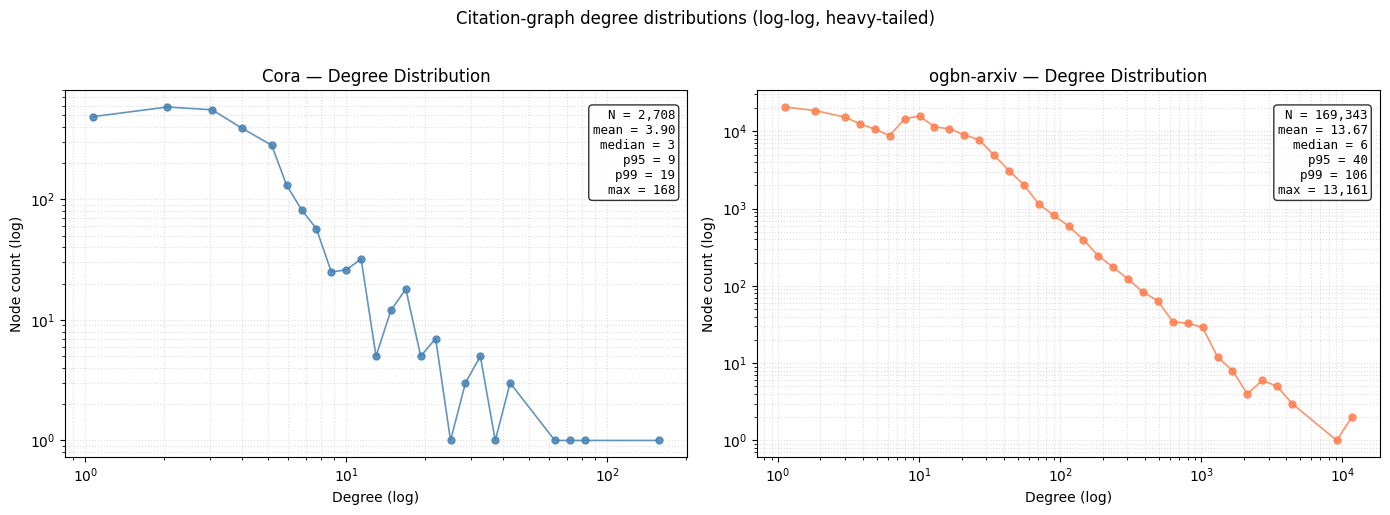


Cora: top 27 nodes (1.0% of graph) account for 9.8% of all edge endpoints

ogbn-arxiv: top 1693 nodes (1.0% of graph) account for 21.4% of all edge endpoints


In [4]:
# Step 4: Degree Distribution (log-log)
"""
Visualize the scale-free / power-law signature common in citation
graphs: most nodes have few neighbors, a small tail of hubs have
thousands. Matters for GNNs because mean-aggregation over
heavy-tailed neighborhoods dilutes signal — motivation for GAT's
attention weighting (V3) and GraphSAGE's neighbor sampling (V2).
"""

print("=" * 60)
print("[3/7] Degree Distribution")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, data, color) in zip(axes, [
    ('Cora', cora, 'steelblue'),
    ('ogbn-arxiv', arxiv, 'coral'),
]):
    degrees = torch.bincount(data.edge_index[1], minlength=data.num_nodes).cpu().numpy()

    # Log-spaced bins for clean log-log histogram
    d_max = int(degrees.max())
    bins = np.logspace(0, np.log10(d_max + 1), 40)
    counts, edges = np.histogram(degrees[degrees > 0], bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])

    ax.loglog(centers[counts > 0], counts[counts > 0],
              'o-', color=color, ms=5, lw=1.2, alpha=0.85)
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Node count (log)')
    ax.set_title(f'{name} — Degree Distribution')
    ax.grid(True, which='both', ls=':', alpha=0.4)

    # Summary stats as inset text
    p50 = int(np.percentile(degrees, 50))
    p95 = int(np.percentile(degrees, 95))
    p99 = int(np.percentile(degrees, 99))
    ax.text(0.98, 0.95,
            f"N = {len(degrees):,}\n"
            f"mean = {degrees.mean():.2f}\n"
            f"median = {p50}\n"
            f"p95 = {p95}\n"
            f"p99 = {p99}\n"
            f"max = {d_max:,}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Citation-graph degree distributions (log-log, heavy-tailed)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the hub skew
for name, data in [('Cora', cora), ('ogbn-arxiv', arxiv)]:
    degrees = torch.bincount(data.edge_index[1], minlength=data.num_nodes).cpu().numpy()
    total = degrees.sum()
    # What fraction of edges touch the top 1% of nodes?
    top1pct_n = max(1, int(len(degrees) * 0.01))
    top_k = np.sort(degrees)[-top1pct_n:]
    frac = top_k.sum() / total * 100
    print(f"\n{name}: top {top1pct_n} nodes ({100 * top1pct_n / len(degrees):.1f}% of graph) "
          f"account for {frac:.1f}% of all edge endpoints")

[4/7] Class Distribution


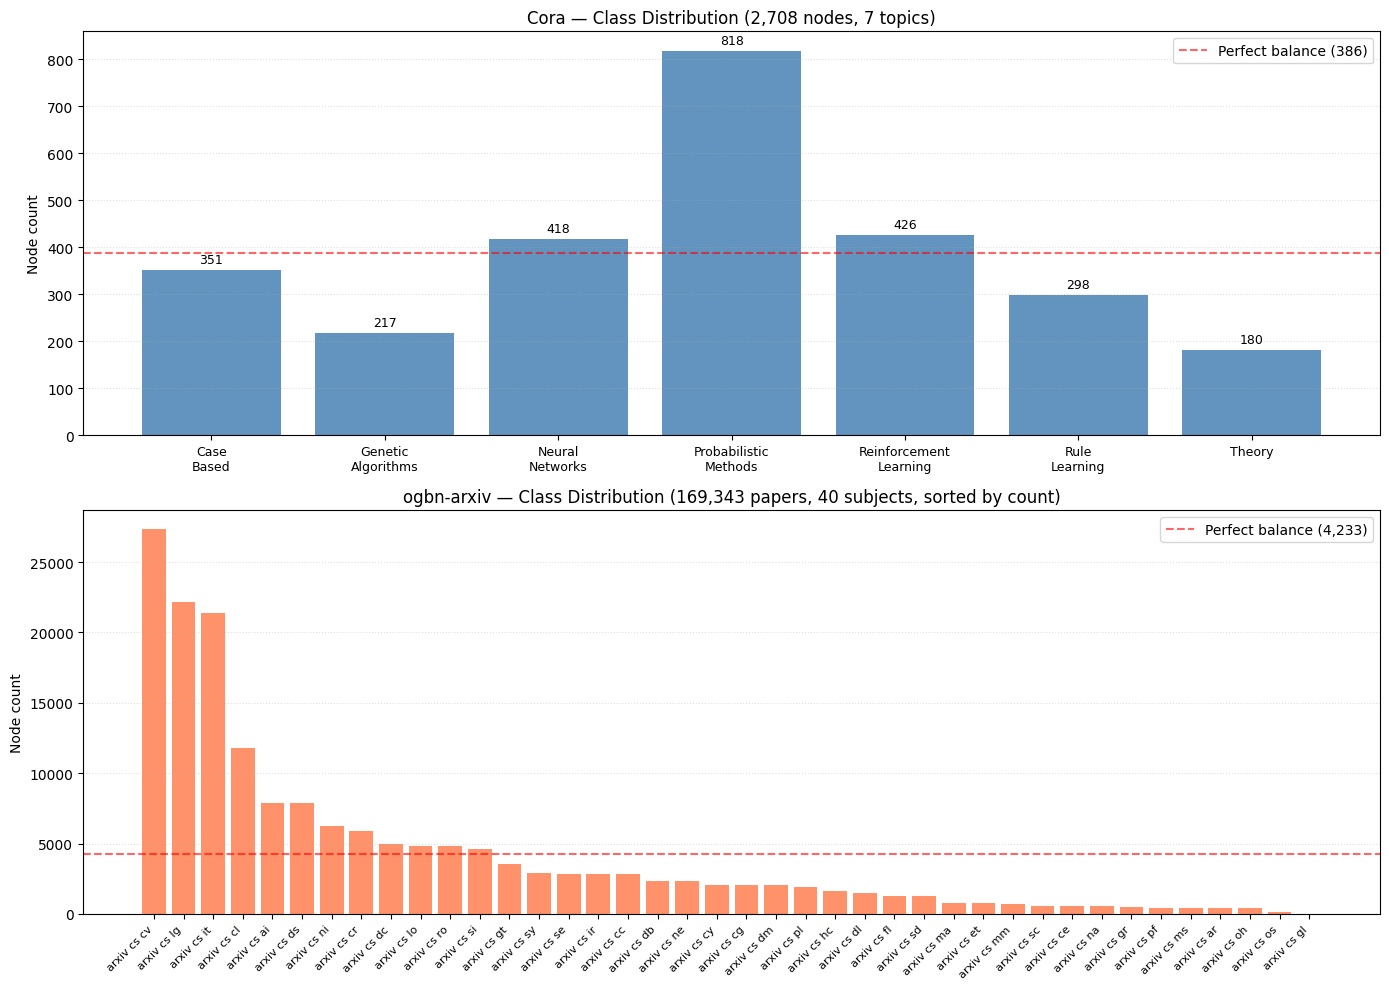


Cora class counts (index order):
    0: Case_Based                  351
    1: Genetic_Algorithms          217
    2: Neural_Networks             418
    3: Probabilistic_Methods       818
    4: Reinforcement_Learning      426
    5: Rule_Learning               298
    6: Theory                      180
    Imbalance ratio (max/min): 4.54

ogbn-arxiv class counts (top 5 and bottom 5):
    16: arxiv cs cv   27,321
    24: arxiv cs lg   22,187
    28: arxiv cs it   21,406
    30: arxiv cs cl   11,814
    10: arxiv cs ai    7,869
    ...
    32: arxiv cs ms      411
    15: arxiv cs ar      403
    21: arxiv cs oh      393
    35: arxiv cs os      127
    12: arxiv cs gl       29
    Imbalance ratio (max/min): 942.1


In [5]:
# Step 5: Class Distribution

"""
Surface class imbalance in both graphs. Cora's 7 classes are
moderately balanced (Kipf's transductive split labels exactly
20 per class for training). arxiv's 40 subject areas are heavily
imbalanced — a few cs.LG / cs.CV papers dominate, rare subfields
have sparse labels. Imbalance affects macro F1 interpretation.
"""

import pandas as pd

print("=" * 60)
print("[4/7] Class Distribution")
print("=" * 60)

# Load arxiv class names from OGB's shipped mapping
# OGB filename: labelidx2arxivcategeory.csv.gz (sic — typo in OGB source)
arxiv_mapping_path = os.path.join(
    ARXIV_ROOT, 'ogbn_arxiv', 'mapping', 'labelidx2arxivcategeory.csv.gz',
)
arxiv_names_df = pd.read_csv(arxiv_mapping_path)
# Two columns: 'label idx' and 'arxiv category'
ARXIV_CLASS_NAMES = arxiv_names_df['arxiv category'].tolist()
assert len(ARXIV_CLASS_NAMES) == 40, f"Expected 40, got {len(ARXIV_CLASS_NAMES)}"

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cora — all 7 classes labeled
cora_counts = np.bincount(cora.y.numpy())
axes[0].bar(range(7), cora_counts, color='steelblue', alpha=0.85)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([n.replace('_', '\n') for n in CORA_CLASS_NAMES],
                        fontsize=9)
axes[0].set_ylabel('Node count')
axes[0].set_title(f'Cora — Class Distribution ({cora.num_nodes:,} nodes, 7 topics)')
axes[0].axhline(cora.num_nodes / 7, color='red', ls='--', alpha=0.6,
                label=f'Perfect balance ({cora.num_nodes // 7})')
for i, c in enumerate(cora_counts):
    axes[0].text(i, c + 15, str(c), ha='center', fontsize=9)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', ls=':', alpha=0.4)

# arxiv — 40 classes, sorted descending by count for readability
arxiv_counts = np.bincount(arxiv.y.numpy(), minlength=40)
order = np.argsort(arxiv_counts)[::-1]
axes[1].bar(range(40), arxiv_counts[order], color='coral', alpha=0.85)
axes[1].set_xticks(range(40))
axes[1].set_xticklabels([ARXIV_CLASS_NAMES[i] for i in order],
                        rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Node count')
axes[1].set_title(f'ogbn-arxiv — Class Distribution '
                  f'({arxiv.num_nodes:,} papers, 40 subjects, sorted by count)')
axes[1].axhline(arxiv.num_nodes / 40, color='red', ls='--', alpha=0.6,
                label=f'Perfect balance ({arxiv.num_nodes // 40:,})')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratios
print(f"\nCora class counts (index order):")
for i, (name, c) in enumerate(zip(CORA_CLASS_NAMES, cora_counts)):
    print(f"    {i}: {name:<25} {c:>5,}")
print(f"    Imbalance ratio (max/min): {cora_counts.max() / cora_counts.min():.2f}")

print(f"\nogbn-arxiv class counts (top 5 and bottom 5):")
for i in order[:5]:
    print(f"    {i:>2}: {ARXIV_CLASS_NAMES[i]:<12} {arxiv_counts[i]:>7,}")
print(f"    ...")
for i in order[-5:]:
    print(f"    {i:>2}: {ARXIV_CLASS_NAMES[i]:<12} {arxiv_counts[i]:>7,}")
print(f"    Imbalance ratio (max/min): {arxiv_counts.max() / arxiv_counts.min():.1f}")

[5/7] Label Homophily

Cora
    Edge homophily:     0.8100   (81.0% of edges are same-class)
    Random baseline:    0.1796   (expected if labels ~ edges)
    Homophily gap:      +0.6304   (headroom for message passing)

ogbn-arxiv
    Edge homophily:     0.6542   (65.4% of edges are same-class)
    Random baseline:    0.0771   (expected if labels ~ edges)
    Homophily gap:      +0.5772   (headroom for message passing)


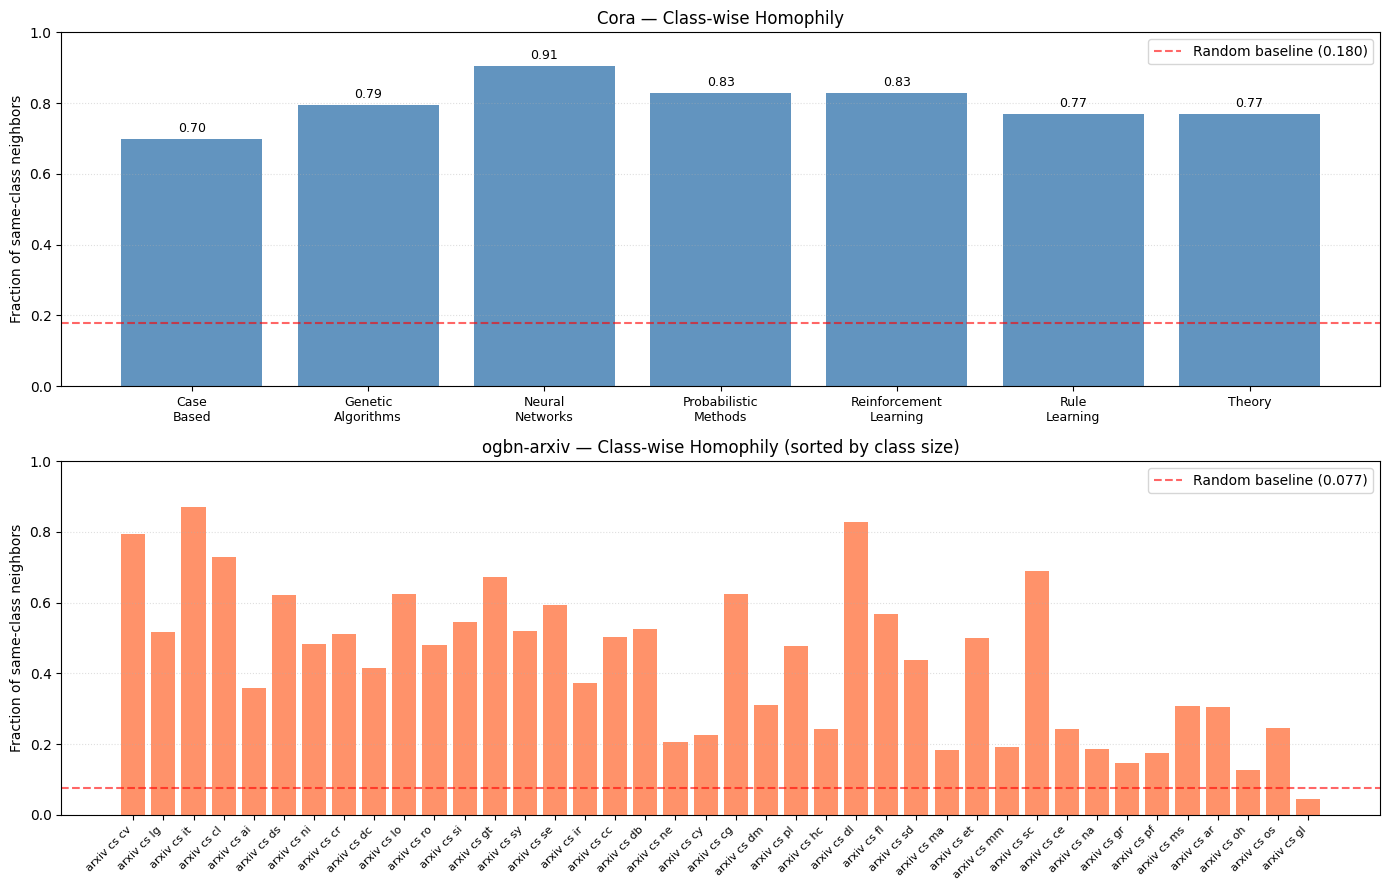

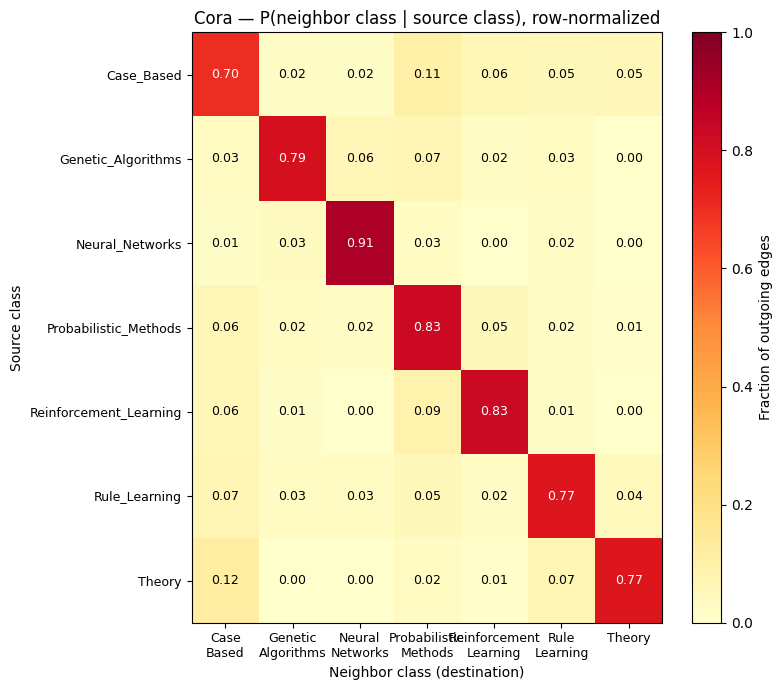

In [6]:
# Step 6: Label Homophily

"""
Homophily = fraction of edges connecting same-class nodes.
This is the single strongest motivator for message passing:
if citations connect same-class papers, neighbor aggregation
is informative signal. If they're random, it's noise.

Edge homophily h = P(y_u == y_v | (u, v) in E)
Random baseline (if labels independent of edges) = sum_c p_c^2
"""

print("=" * 60)
print("[5/7] Label Homophily")
print("=" * 60)

def edge_homophily(edge_index, y):
    # Fraction of edges whose endpoints share a class label
    src, dst = edge_index
    same = (y[src] == y[dst]).float()
    return float(same.mean())


def random_baseline(y):
    #E xpected homophily if labels were independent of edges: sum p_c^2
    counts = torch.bincount(y)
    p = counts.float() / y.numel()
    return float((p * p).sum())


def class_wise_homophily(edge_index, y, n_classes):
    """
    Per-class homophily: for each class c, fraction of edges
    originating from class-c nodes that land on a same-class neighbor.
    """
    src, dst = edge_index
    out = torch.zeros(n_classes)
    for c in range(n_classes):
        mask = y[src] == c
        if mask.sum() == 0:
            out[c] = float('nan')
        else:
            out[c] = (y[dst][mask] == c).float().mean()
    return out.numpy()

# Overall homophily + random baseline
for name, data, n_classes in [('Cora', cora, 7), ('ogbn-arxiv', arxiv, 40)]:
    h = edge_homophily(data.edge_index, data.y)
    baseline = random_baseline(data.y)
    gap = h - baseline
    print(f"\n{name}")
    print(f"    Edge homophily:     {h:.4f}   ({h*100:.1f}% of edges are same-class)")
    print(f"    Random baseline:    {baseline:.4f}   (expected if labels ~ edges)")
    print(f"    Homophily gap:      {gap:+.4f}   (headroom for message passing)")

# Class-wise homophily
cora_cw = class_wise_homophily(cora.edge_index, cora.y, 7)
arxiv_cw = class_wise_homophily(arxiv.edge_index, arxiv.y, 40)
arxiv_counts_local = np.bincount(arxiv.y.numpy(), minlength=40)
order = np.argsort(arxiv_counts_local)[::-1]  # descending by class size

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Cora — all 7 classes
axes[0].bar(range(7), cora_cw, color='steelblue', alpha=0.85)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([n.replace('_', '\n') for n in CORA_CLASS_NAMES], fontsize=9)
axes[0].set_ylabel('Fraction of same-class neighbors')
axes[0].set_ylim(0, 1)
axes[0].set_title('Cora — Class-wise Homophily')
axes[0].axhline(random_baseline(cora.y), color='red', ls='--', alpha=0.6,
                label=f'Random baseline ({random_baseline(cora.y):.3f})')
for i, v in enumerate(cora_cw):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', ls=':', alpha=0.4)

# arxiv — 40 classes sorted by size (dominant subjects first)
axes[1].bar(range(40), arxiv_cw[order], color='coral', alpha=0.85)
axes[1].set_xticks(range(40))
axes[1].set_xticklabels([ARXIV_CLASS_NAMES[i] for i in order],
                        rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Fraction of same-class neighbors')
axes[1].set_ylim(0, 1)
axes[1].set_title('ogbn-arxiv — Class-wise Homophily (sorted by class size)')
axes[1].axhline(random_baseline(arxiv.y), color='red', ls='--', alpha=0.6,
                label=f'Random baseline ({random_baseline(arxiv.y):.3f})')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_homophily.png', dpi=150, bbox_inches='tight')
plt.show()

# Cora 7x7 edge-class heatmap (where do cross-class citations land?)
edge_matrix = np.zeros((7, 7), dtype=int)
src, dst = cora.edge_index.numpy()
for s, d in zip(cora.y.numpy()[src], cora.y.numpy()[dst]):
    edge_matrix[s, d] += 1
# Row-normalize to P(dst class | src class)
row_norm = edge_matrix / edge_matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(row_norm, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{row_norm[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if row_norm[i, j] < 0.5 else 'white')
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels([n.replace('_', '\n') for n in CORA_CLASS_NAMES], fontsize=9)
ax.set_yticklabels(CORA_CLASS_NAMES, fontsize=9)
ax.set_xlabel('Neighbor class (destination)')
ax.set_ylabel('Source class')
ax.set_title('Cora — P(neighbor class | source class), row-normalized')
plt.colorbar(im, ax=ax, label='Fraction of outgoing edges')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_cora_edge_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

[6/7] Train/Val/Test Split Composition


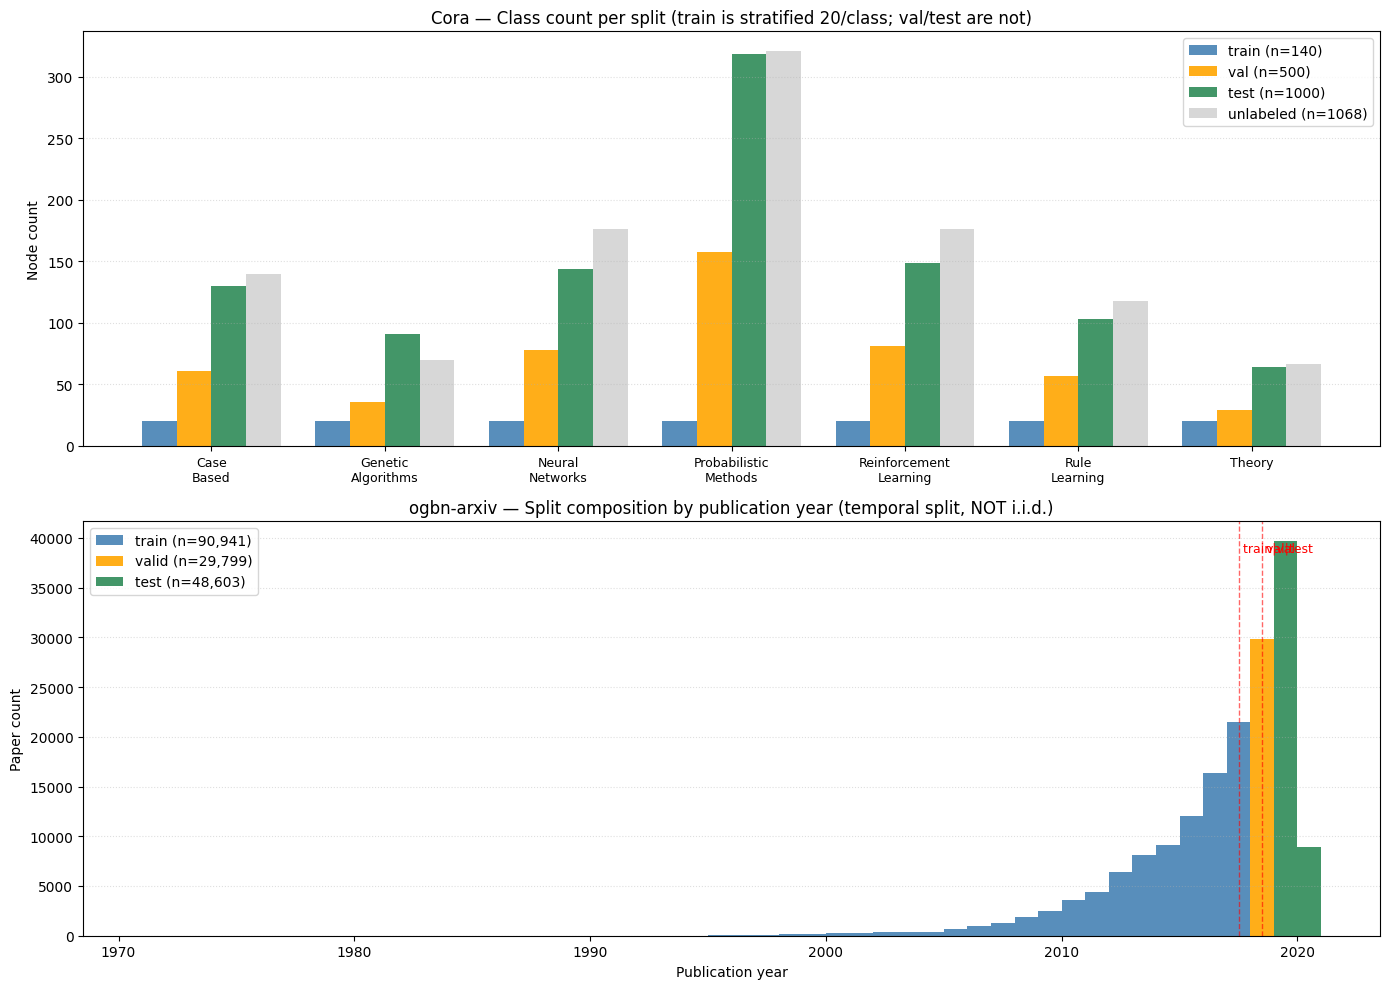


Cora split composition (class index : train/val/test/unlab)
    0 Case_Based                 20/ 61/ 130/ 140
    1 Genetic_Algorithms         20/ 36/  91/  70
    2 Neural_Networks            20/ 78/ 144/ 176
    3 Probabilistic_Methods      20/158/ 319/ 321
    4 Reinforcement_Learning     20/ 81/ 149/ 176
    5 Rule_Learning              20/ 57/ 103/ 118
    6 Theory                     20/ 29/  64/  67

ogbn-arxiv temporal drift:
    Train years: 32 unique, range [1971, 2017]
    Test years:  [2019, 2020] (none appear in train: True)

ogbn-arxiv class-proportion shifts train -> test (top 5 absolute):
    arxiv cs lg  train  7.69% -> test 22.10% (+14.41pp)
    arxiv cs it  train 17.91% -> test  5.86% (-12.04pp)
    arxiv cs cv  train 10.99% -> test 21.56% (+10.56pp)
    arxiv cs cl  train  4.77% -> test  9.53% (+4.76pp)
    arxiv cs ds  train  5.97% -> test  2.91% (-3.06pp)


In [ ]:
# Step 7: Train/Val/Test Split Composition

"""
Surfaces how the two datasets' splits differ structurally:
  - Cora: fixed Kipf mask (20 train / 500 val / 1000 test / 1068 unlabeled),
          stratified only in the train set (20 nodes per class by construction).
  - ogbn-arxiv: temporal split by publication year. Tests whether the model
                handles concept drift as the field evolved 2018 -> 2020.
Both views affect how we interpret macro F1 later.
"""

print("=" * 60)
print("[6/7] Train/Val/Test Split Composition")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cora — class × split grouped bars
cora_y = cora.y.numpy()
splits_cora = {
    'train': cora.train_mask.numpy(),
    'val':   cora.val_mask.numpy(),
    'test':  cora.test_mask.numpy(),
    'unlabeled': ~(cora.train_mask | cora.val_mask | cora.test_mask).numpy(),
}
mat = np.zeros((4, 7), dtype=int)
for i, (_, mask) in enumerate(splits_cora.items()):
    mat[i] = np.bincount(cora_y[mask], minlength=7)

bar_w = 0.2
x = np.arange(7)
colors = ['steelblue', 'orange', 'seagreen', 'lightgray']
for i, (split_name, counts) in enumerate(zip(splits_cora.keys(), mat)):
    axes[0].bar(x + (i - 1.5) * bar_w, counts, bar_w,
                label=f'{split_name} (n={counts.sum()})',
                color=colors[i], alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace('_', '\n') for n in CORA_CLASS_NAMES], fontsize=9)
axes[0].set_ylabel('Node count')
axes[0].set_title('Cora — Class count per split '
                  '(train is stratified 20/class; val/test are not)')
axes[0].legend()
axes[0].grid(axis='y', ls=':', alpha=0.4)

# arxiv — year distribution per split (stacked histogram)
years = arxiv.node_year.view(-1).numpy()
train_years_np = years[arxiv_split['train'].numpy()]
valid_years_np = years[arxiv_split['valid'].numpy()]
test_years_np  = years[arxiv_split['test'].numpy()]

year_bins = np.arange(years.min(), years.max() + 2)
axes[1].hist(
    [train_years_np, valid_years_np, test_years_np],
    bins=year_bins,
    label=[f'train (n={len(train_years_np):,})',
           f'valid (n={len(valid_years_np):,})',
           f'test (n={len(test_years_np):,})'],
    color=['steelblue', 'orange', 'seagreen'],
    alpha=0.9, stacked=True,
)
axes[1].set_xlabel('Publication year')
axes[1].set_ylabel('Paper count')
axes[1].set_title('ogbn-arxiv — Split composition by publication year '
                  '(temporal split, NOT i.i.d.)')
axes[1].legend()
axes[1].grid(axis='y', ls=':', alpha=0.4)
# Visual separators at split boundaries
axes[1].axvline(2017.5, color='red', ls='--', alpha=0.6, lw=1)
axes[1].axvline(2018.5, color='red', ls='--', alpha=0.6, lw=1)
axes[1].text(2017.5, axes[1].get_ylim()[1] * 0.95, ' train|val',
             fontsize=9, color='red', ha='left', va='top')
axes[1].text(2018.5, axes[1].get_ylim()[1] * 0.95, ' val|test',
             fontsize=9, color='red', ha='left', va='top')

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_split_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nCora split composition (class index : train/val/test/unlab)")
for c in range(7):
    print(f"    {c} {CORA_CLASS_NAMES[c]:<25} "
          f"{mat[0, c]:>3}/{mat[1, c]:>3}/{mat[2, c]:>4}/{mat[3, c]:>4}")

# arxiv: what fraction of test years do NOT appear in train? (pure drift check)
train_years_set = set(np.unique(train_years_np).tolist())
test_years_set = set(np.unique(test_years_np).tolist())
unseen_years = test_years_set - train_years_set
print(f"\nogbn-arxiv temporal drift:")
print(f"    Train years: {len(train_years_set)} unique, "
      f"range [{min(train_years_set)}, {max(train_years_set)}]")
print(f"    Test years:  {sorted(test_years_set)} "
      f"(none appear in train: {sorted(unseen_years) == sorted(test_years_set)})")

# arxiv: class distribution drift — how do test class proportions
# compare to train class proportions? Large deltas = subfield shift
train_class_dist = np.bincount(
    arxiv.y[arxiv_split['train']].numpy(), minlength=40,
) / len(arxiv_split['train'])
test_class_dist = np.bincount(
    arxiv.y[arxiv_split['test']].numpy(), minlength=40,
) / len(arxiv_split['test'])
deltas = test_class_dist - train_class_dist
top_shifts = np.argsort(np.abs(deltas))[-5:][::-1]
print(f"\nogbn-arxiv class-proportion shifts train -> test (top 5 absolute):")
for i in top_shifts:
    direction = '+' if deltas[i] > 0 else '-'
    print(f"    {ARXIV_CLASS_NAMES[i]:<12} "
          f"train {train_class_dist[i]*100:5.2f}% -> test {test_class_dist[i]*100:5.2f}% "
          f"({direction}{abs(deltas[i])*100:.2f}pp)")

[7/7] Cora Small-Graph Visualization
    Full graph: 2708 nodes / 5278 edges
    Largest CC: 2485 nodes / 5069 edges (91.8% of nodes)
    Computing spring layout (this takes ~15-30s)...


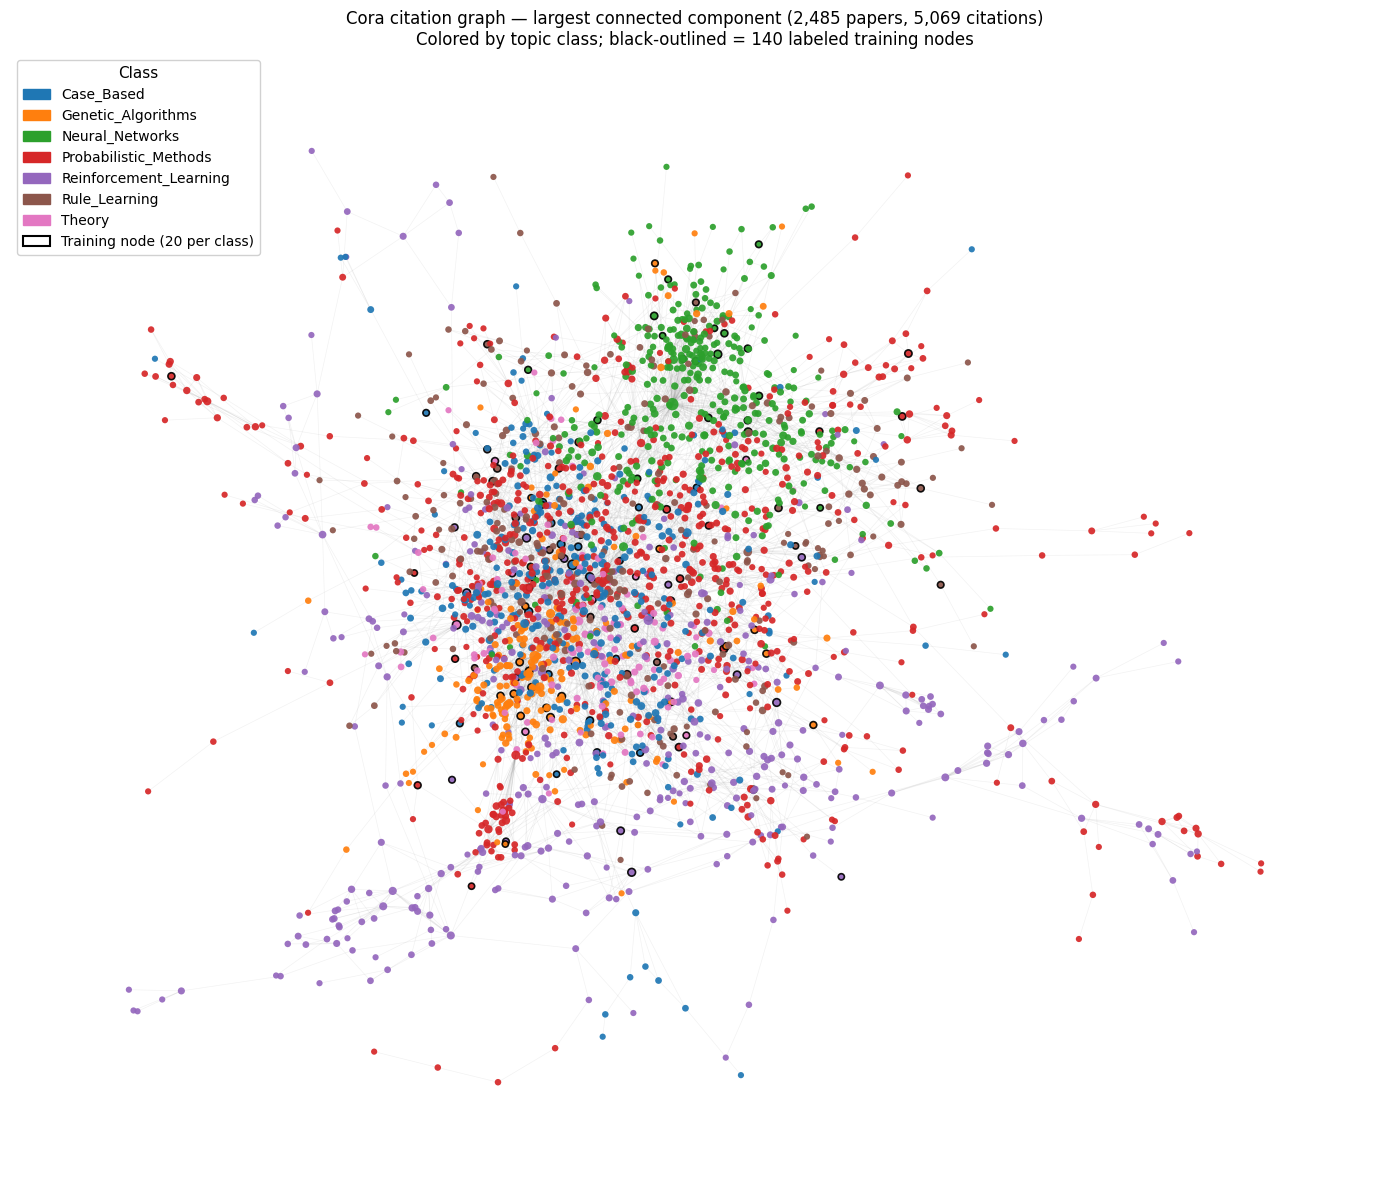


    Saved ../data/raw/eda_gnn/eda_cora_graph.png

EDA complete
All plots: ../data/raw/eda_gnn/


In [8]:
# Step 8: Cora Small-Graph Visualization
"""
The educational finale — visualize Cora's 2,708 nodes as a 2D
layout colored by class. Two observations the reader should see:

1. Clear class clusters (homophily visualized) — confirms why
   message passing works: nodes of the same class cluster
   tightly in the citation topology.

2. Inter-class bridges exist but are rare. These are the edges
   that make classification non-trivial at the boundaries.

Restricted to the largest connected component (2,485 nodes) for
visual clarity; the 77 small components would scatter the plot.
"""

import networkx as nx
from torch_geometric.utils import to_networkx

print("=" * 60)
print("[7/7] Cora Small-Graph Visualization")
print("=" * 60)

# Extract the largest connected component — the 77 small fragments
# would otherwise clutter the layout without adding any structure
G_full = to_networkx(cora, to_undirected=True, remove_self_loops=True)
lcc_nodes = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(lcc_nodes).copy()
node_list = list(G.nodes())
print(f"    Full graph: {G_full.number_of_nodes()} nodes / "
      f"{G_full.number_of_edges()} edges")
print(f"    Largest CC: {G.number_of_nodes()} nodes / "
      f"{G.number_of_edges()} edges "
      f"({G.number_of_nodes() / G_full.number_of_nodes() * 100:.1f}% of nodes)")

# Compute spring layout (Fruchterman-Reingold)
# k controls ideal edge length; iterations trades quality for time
print("    Computing spring layout (this takes ~15-30s)...")
pos = nx.spring_layout(G, k=0.18, iterations=60, seed=RANDOM_STATE)

# Color each node by its class
y_np = cora.y.numpy()
node_colors = [y_np[n] for n in node_list]

# Size each node by its degree (sqrt to compress hubs)
degrees_lcc = np.array([G.degree(n) for n in node_list])
node_sizes = 15 + 5 * np.sqrt(degrees_lcc)

# Mark the 140 train nodes with a black outline (they're the labeled anchors
# that GNNs back-propagate from; rest are inferred transductively)
train_nodes = set(np.where(cora.train_mask.numpy())[0])
edge_colors = ['black' if n in train_nodes else 'none' for n in node_list]
edge_widths = [1.2 if n in train_nodes else 0 for n in node_list]

# Draw
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.10, width=0.5, edge_color='gray')
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    cmap=plt.get_cmap('tab10'), vmin=0, vmax=9,
    edgecolors=edge_colors, linewidths=edge_widths,
    alpha=0.92,
)

# Custom class-color legend
from matplotlib.patches import Patch
cmap = plt.get_cmap('tab10')
legend_handles = [
    Patch(color=cmap(i), label=CORA_CLASS_NAMES[i]) for i in range(7)
]
legend_handles.append(
    Patch(facecolor='white', edgecolor='black', linewidth=1.5,
          label='Training node (20 per class)'),
)
ax.legend(handles=legend_handles, loc='upper left', fontsize=10,
          framealpha=0.9, title='Class', title_fontsize=11)

ax.set_title(
    f'Cora citation graph — largest connected component '
    f'({G.number_of_nodes():,} papers, {G.number_of_edges():,} citations)\n'
    f'Colored by topic class; black-outlined = 140 labeled training nodes',
    fontsize=12,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_cora_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n    Saved {EDA_DIR}/eda_cora_graph.png")
print("\n" + "=" * 60)
print("EDA complete")
print("=" * 60)
print(f"All plots: {EDA_DIR}/")